In [1]:
from google.colab import files
uploaded = files.upload()

Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)
df.head()

Shape: (7043, 21)

Column Names:
 ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Missing Values:
 customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Data Types:
 customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           ob

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Fix TotalCharges column (it has spaces, should be numeric)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Drop rows with missing values (only 11 rows)
df.dropna(inplace=True)

# Convert Churn to binary (Yes=1, No=0)
df['Churn_Binary'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Convert SeniorCitizen to readable format
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

print("Cleaned Shape:", df.shape)
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print("\nChurn Rate:", round(df['Churn_Binary'].mean() * 100, 2), "%")

Cleaned Shape: (7032, 22)

Churn Distribution:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Rate: 26.58 %


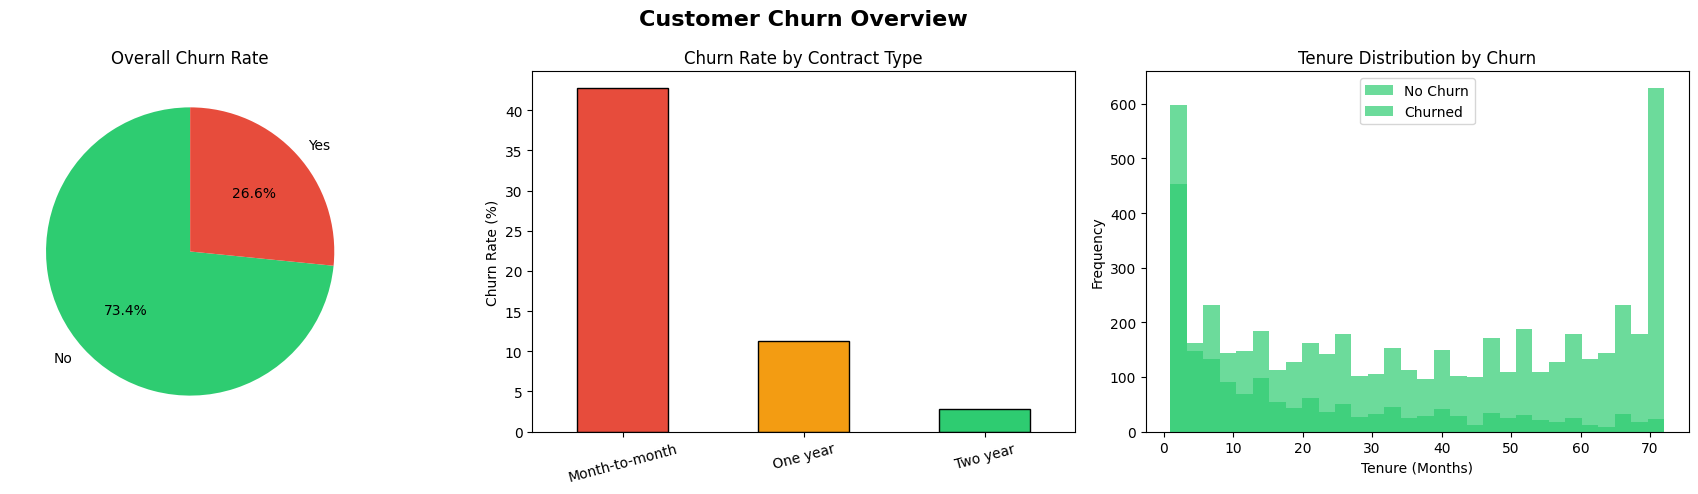

Chart saved!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Churn Overview', fontsize=16, fontweight='bold')

# Chart 1 - Churn Distribution
colors = ['#2ecc71', '#e74c3c']
df['Churn'].value_counts().plot(kind='pie', ax=axes[0], autopct='%1.1f%%',
                                 colors=colors, startangle=90)
axes[0].set_title('Overall Churn Rate')
axes[0].set_ylabel('')

# Chart 2 - Churn by Contract Type
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100
contract_churn.plot(kind='bar', ax=axes[1], color=['#e74c3c','#f39c12','#2ecc71'],
                    edgecolor='black')
axes[1].set_title('Churn Rate by Contract Type')
axes[1].set_ylabel('Churn Rate (%)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

# Chart 3 - Churn by Tenure
df.groupby('Churn')['tenure'].plot(kind='hist', ax=axes[2], alpha=0.7,
                                    bins=30, color=['#2ecc71','#e74c3c'])
axes[2].set_title('Tenure Distribution by Churn')
axes[2].set_xlabel('Tenure (Months)')
axes[2].legend(['No Churn', 'Churned'])

plt.tight_layout()
plt.savefig('churn_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

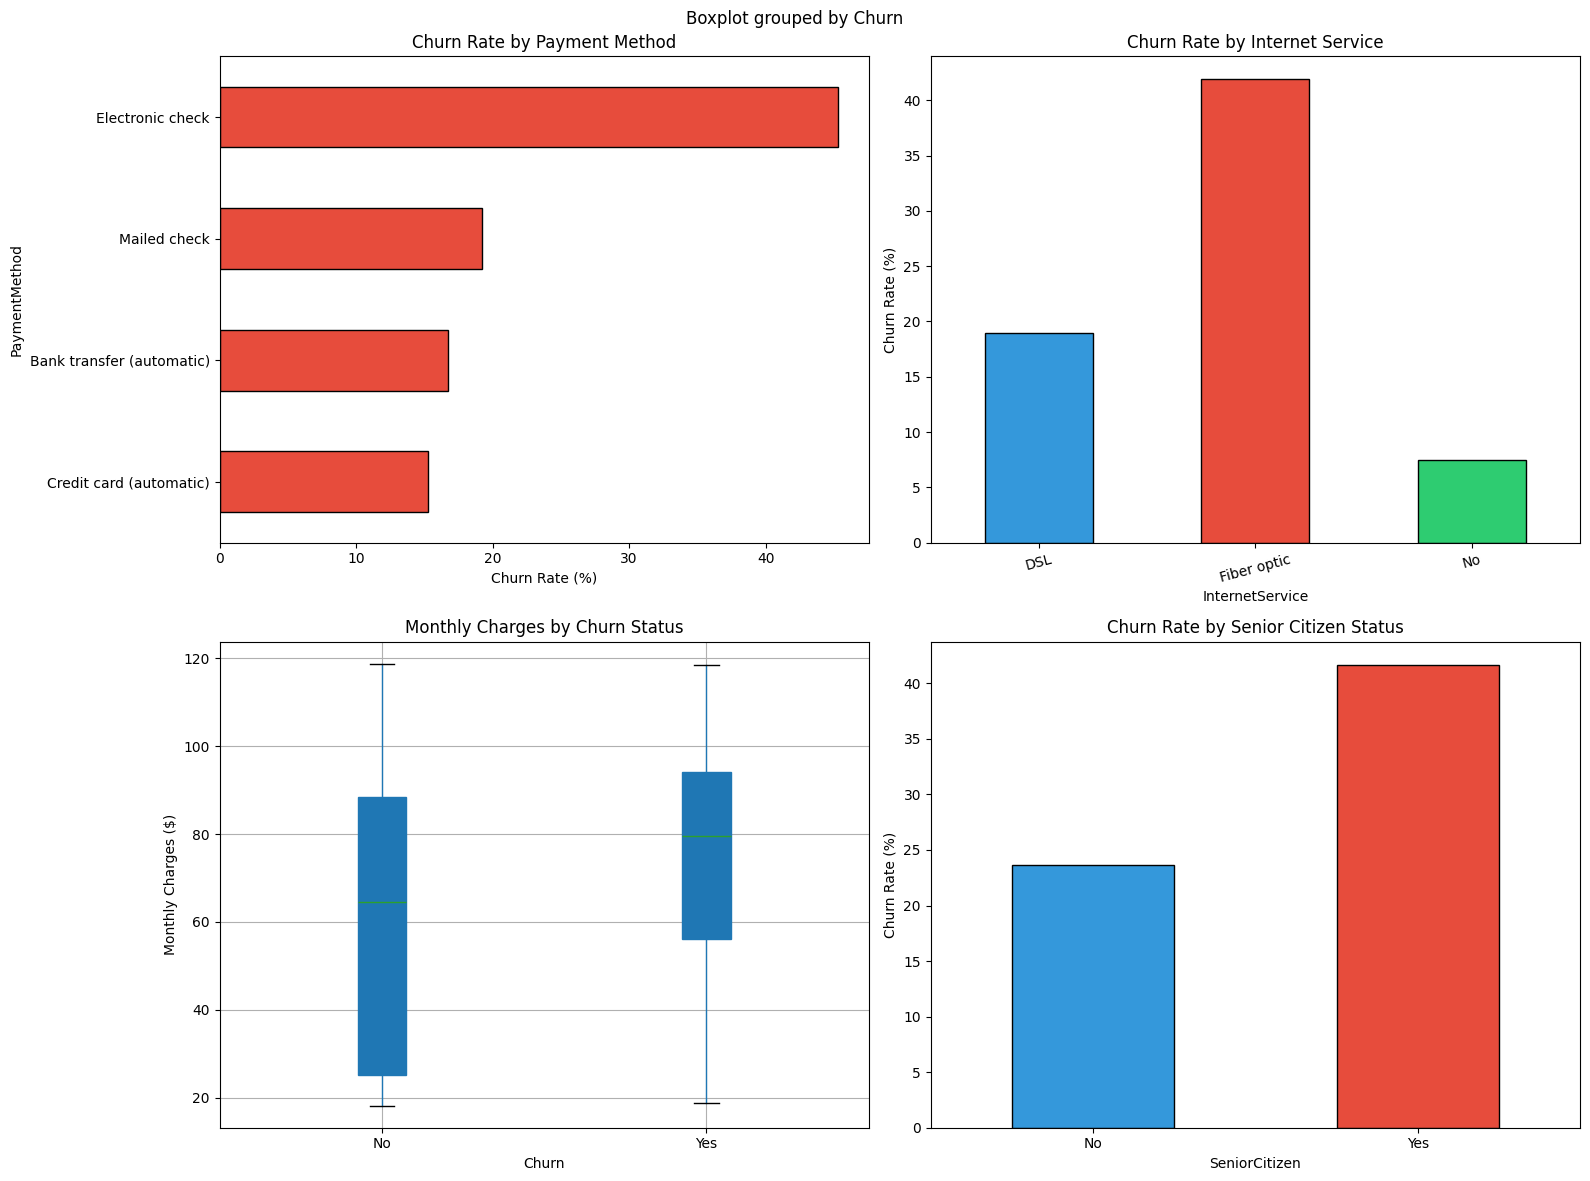

Chart saved!


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Churn Driver Analysis', fontsize=16, fontweight='bold')

# Chart 1 - Churn by Payment Method
payment_churn = df.groupby('PaymentMethod')['Churn_Binary'].mean() * 100
payment_churn.sort_values(ascending=True).plot(kind='barh', ax=axes[0,0],
                                                color='#e74c3c', edgecolor='black')
axes[0,0].set_title('Churn Rate by Payment Method')
axes[0,0].set_xlabel('Churn Rate (%)')

# Chart 2 - Churn by Internet Service
internet_churn = df.groupby('InternetService')['Churn_Binary'].mean() * 100
internet_churn.plot(kind='bar', ax=axes[0,1], color=['#3498db','#e74c3c','#2ecc71'],
                    edgecolor='black')
axes[0,1].set_title('Churn Rate by Internet Service')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].tick_params(axis='x', rotation=15)

# Chart 3 - Monthly Charges vs Churn
df.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1,0],
           patch_artist=True)
axes[1,0].set_title('Monthly Charges by Churn Status')
axes[1,0].set_xlabel('Churn')
axes[1,0].set_ylabel('Monthly Charges ($)')

# Chart 4 - Churn by Senior Citizen
senior_churn = df.groupby('SeniorCitizen')['Churn_Binary'].mean() * 100
senior_churn.plot(kind='bar', ax=axes[1,1], color=['#3498db','#e74c3c'],
                  edgecolor='black')
axes[1,1].set_title('Churn Rate by Senior Citizen Status')
axes[1,1].set_ylabel('Churn Rate (%)')
axes[1,1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('churn_drivers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

In [6]:
import sqlite3

# Load data into SQLite database
conn = sqlite3.connect('churn_database.db')
df.to_sql('customers', conn, if_exists='replace', index=False)
print("Database created successfully!")

# Query 1 - Overall Churn Rate
print("\n--- 1. Overall Churn Rate ---")
q1 = pd.read_sql_query("""
    SELECT Churn, COUNT(*) as total_customers,
    ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM customers), 2) as percentage
    FROM customers GROUP BY Churn
""", conn)
print(q1)

# Query 2 - Churn by Contract Type
print("\n--- 2. Churn Rate by Contract Type ---")
q2 = pd.read_sql_query("""
    SELECT Contract, COUNT(*) as total,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_rate
    FROM customers GROUP BY Contract ORDER BY churn_rate DESC
""", conn)
print(q2)

# Query 3 - Revenue at Risk
print("\n--- 3. Monthly Revenue at Risk ---")
q3 = pd.read_sql_query("""
    SELECT ROUND(SUM(MonthlyCharges),2) as monthly_revenue_lost,
    COUNT(*) as churned_customers
    FROM customers WHERE Churn='Yes'
""", conn)
print(q3)

# Query 4 - Churn by Tenure Group
print("\n--- 4. Churn by Tenure Group ---")
q4 = pd.read_sql_query("""
    SELECT
    CASE WHEN tenure <= 12 THEN '0-12 months'
         WHEN tenure <= 24 THEN '13-24 months'
         WHEN tenure <= 48 THEN '25-48 months'
         ELSE '49+ months' END as tenure_group,
    COUNT(*) as total,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_rate
    FROM customers GROUP BY tenure_group ORDER BY churn_rate DESC
""", conn)
print(q4)

# Query 5 - Churn by Payment Method
print("\n--- 5. Churn by Payment Method ---")
q5 = pd.read_sql_query("""
    SELECT PaymentMethod, COUNT(*) as total,
    SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END) as churned,
    ROUND(SUM(CASE WHEN Churn='Yes' THEN 1 ELSE 0 END)*100.0/COUNT(*),2) as churn_rate
    FROM customers GROUP BY PaymentMethod ORDER BY churn_rate DESC
""", conn)
print(q5)

print("\nAll SQL queries executed successfully!")

Database created successfully!

--- 1. Overall Churn Rate ---
  Churn  total_customers  percentage
0    No             5163       73.42
1   Yes             1869       26.58

--- 2. Churn Rate by Contract Type ---
         Contract  total  churned  churn_rate
0  Month-to-month   3875     1655       42.71
1        One year   1472      166       11.28
2        Two year   1685       48        2.85

--- 3. Monthly Revenue at Risk ---
   monthly_revenue_lost  churned_customers
0             139130.85               1869

--- 4. Churn by Tenure Group ---
   tenure_group  total  churned  churn_rate
0   0-12 months   2175     1037       47.68
1  13-24 months   1024      294       28.71
2  25-48 months   1594      325       20.39
3    49+ months   2239      213        9.51

--- 5. Churn by Payment Method ---
               PaymentMethod  total  churned  churn_rate
0           Electronic check   2365     1071       45.29
1               Mailed check   1604      308       19.20
2  Bank transfer (au

In [7]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Encode categorical columns
df_ml = df.copy()
le = LabelEncoder()
cat_cols = df_ml.select_dtypes(include='object').columns.tolist()
cat_cols.remove('customerID')
cat_cols.remove('Churn')

for col in cat_cols:
    df_ml[col] = le.fit_transform(df_ml[col])

# Features and target
X = df_ml.drop(['customerID', 'Churn', 'Churn_Binary'], axis=1)
y = df_ml['Churn_Binary']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train XGBoost model
model = XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {round(accuracy*100, 2)}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 78.96%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



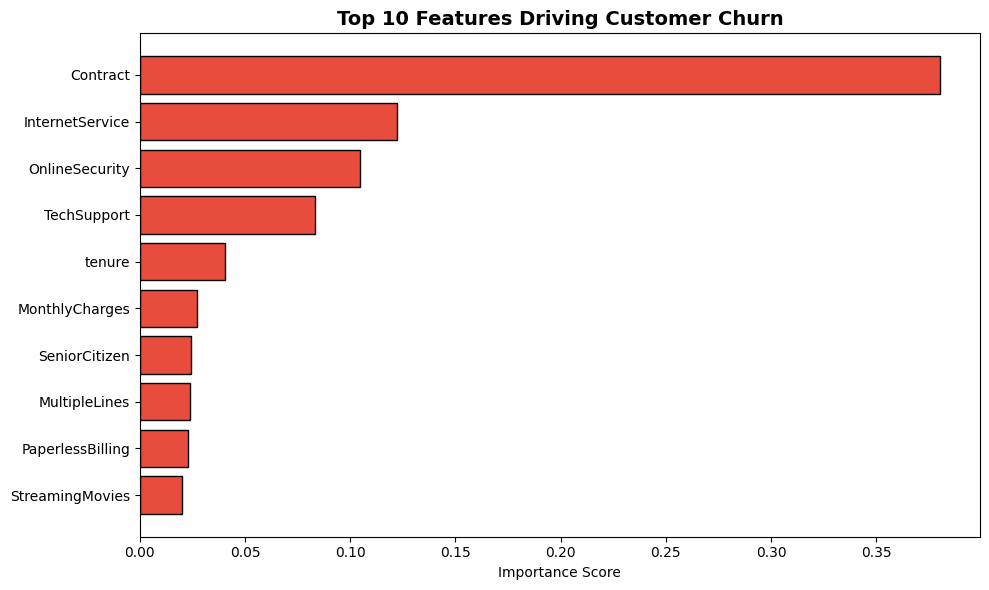

Top churn drivers identified!


In [8]:
# Feature Importance
feat_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=True).tail(10)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'], color='#e74c3c', edgecolor='black')
plt.title('Top 10 Features Driving Customer Churn', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Top churn drivers identified!")

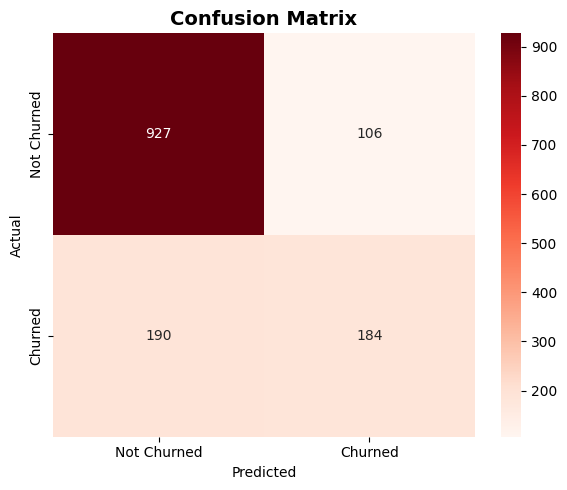

In [9]:
plt.figure(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Not Churned','Churned'],
            yticklabels=['Not Churned','Churned'])
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Key Business Metrics
total_customers = len(df)
churned_customers = df['Churn_Binary'].sum()
churn_rate = df['Churn_Binary'].mean() * 100
monthly_revenue_at_risk = df[df['Churn']=='Yes']['MonthlyCharges'].sum()
avg_tenure_churned = df[df['Churn']=='Yes']['tenure'].mean()
avg_tenure_retained = df[df['Churn']=='No']['tenure'].mean()

# Churn by Contract
contract_churn = df.groupby('Contract')['Churn_Binary'].mean() * 100

# Churn by Tenure Group
df['TenureGroup'] = pd.cut(df['tenure'],
                            bins=[0,12,24,48,72],
                            labels=['0-12 months','13-24 months','25-48 months','49+ months'])
tenure_churn = df.groupby('TenureGroup')['Churn_Binary'].mean() * 100

print("=" * 55)
print("   CUSTOMER CHURN - BUSINESS INTELLIGENCE REPORT")
print("=" * 55)
print(f"\n OVERVIEW")
print(f"  Total Customers       : {total_customers:,}")
print(f"  Churned Customers     : {churned_customers:,}")
print(f"  Churn Rate            : {churn_rate:.2f}%")
print(f"  Monthly Revenue Lost  : ${monthly_revenue_at_risk:,.2f}")

print(f"\n TENURE INSIGHTS")
print(f"  Avg Tenure (Churned)  : {avg_tenure_churned:.1f} months")
print(f"  Avg Tenure (Retained) : {avg_tenure_retained:.1f} months")

print(f"\n CHURN BY CONTRACT TYPE")
for contract, rate in contract_churn.items():
    print(f"  {contract:25s} : {rate:.2f}%")

print(f"\n CHURN BY TENURE GROUP")
for group, rate in tenure_churn.items():
    print(f"  {str(group):25s} : {rate:.2f}%")

print(f"\n KEY RECOMMENDATIONS")
print(f"  1. Target month-to-month customers with loyalty discounts")
print(f"     at month 6 — highest churn risk segment")
print(f"  2. Offer annual contract incentives to new customers")
print(f"     in first 12 months to reduce early churn")
print(f"  3. Focus retention budget on ${monthly_revenue_at_risk:,.0f}/month")
print(f"     revenue at risk from {churned_customers} churned customers")
print(f"  4. Prioritize TechSupport and OnlineSecurity upsells")
print(f"     — customers without these churn significantly more")
print("=" * 55)

   CUSTOMER CHURN - BUSINESS INTELLIGENCE REPORT

 OVERVIEW
  Total Customers       : 7,032
  Churned Customers     : 1,869
  Churn Rate            : 26.58%
  Monthly Revenue Lost  : $139,130.85

 TENURE INSIGHTS
  Avg Tenure (Churned)  : 18.0 months
  Avg Tenure (Retained) : 37.7 months

 CHURN BY CONTRACT TYPE
  Month-to-month            : 42.71%
  One year                  : 11.28%
  Two year                  : 2.85%

 CHURN BY TENURE GROUP
  0-12 months               : 47.68%
  13-24 months              : 28.71%
  25-48 months              : 20.39%
  49+ months                : 9.51%

 KEY RECOMMENDATIONS
  1. Target month-to-month customers with loyalty discounts
     at month 6 — highest churn risk segment
  2. Offer annual contract incentives to new customers
     in first 12 months to reduce early churn
  3. Focus retention budget on $139,131/month
     revenue at risk from 1869 churned customers
  4. Prioritize TechSupport and OnlineSecurity upsells
     — customers without th

In [11]:
# Save cleaned data
df.to_csv('churn_cleaned.csv', index=False)

# Save SQL results
q2.to_csv('sql_contract_churn.csv', index=False)
q4.to_csv('sql_tenure_churn.csv', index=False)
q5.to_csv('sql_payment_churn.csv', index=False)

print("All files saved!")
print("\nFiles in your project:")
import os
for f in os.listdir():
    print(f" -", f)

All files saved!

Files in your project:
 - .config
 - WA_Fn-UseC_-Telco-Customer-Churn.csv
 - churn_cleaned.csv
 - churn_overview.png
 - sql_contract_churn.csv
 - feature_importance.png
 - confusion_matrix.png
 - churn_drivers.png
 - sql_payment_churn.csv
 - sql_tenure_churn.csv
 - churn_database.db
 - sample_data


In [12]:
import shutil
import os

# Create project folder
os.makedirs('churn-project', exist_ok=True)

# Copy all files into it
files_to_save = [
    'churn_cleaned.csv',
    'churn_overview.png',
    'churn_drivers.png',
    'feature_importance.png',
    'confusion_matrix.png',
    'sql_contract_churn.csv',
    'sql_tenure_churn.csv',
    'sql_payment_churn.csv',
    'churn_database.db'
]

for f in files_to_save:
    shutil.copy(f, f'churn-project/{f}')

# Zip and download
shutil.make_archive('churn-project', 'zip', 'churn-project')

from google.colab import files
files.download('churn-project.zip')
print("Downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded!
